## Import necessary libraries

In [26]:
import glob
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import torch
import torchvision.transforms as T
import random
from torch.utils.data import Dataset, DataLoader
import torchvision.utils as vutils
from tqdm import tqdm

### Create necessary functions to create dataset form local storage

In [9]:
# Read the dataset path
def read_data_path(path):
    files = glob.glob(f'{path}/*/*.jpg', recursive=True)
    return files

In [85]:
# After getting the list of imafes path from previous step, make a dataframe for each image path and their corresponding label.
def make_data_csv(image_path_list, transform_data=False):
    labels = []
    transform = []

    for file_path in image_path_list:
        class_name = os.path.basename(os.path.dirname(file_path))
        labels.append(class_name)
        
        if transform_data:
            transform.append(os.path.basename(file_path).split('_')[0])
            
    data_dict = {"Images": image_path_list, "Labels": labels, "Transform" : transform} if transform_data else {"Images": image_path_list, "Labels": labels}
    dataset = pd.DataFrame(data_dict)
        
    return dataset


In [11]:
files = read_data_path(path="/home/ml-shailesh/Desktop/PProject/nepali-text-classification/images")

In [13]:
dataset_df = make_data_csv(image_path_list=files)

In [14]:
# Read images from path
def read_images(image_path, size=()):
    image = Image.open(image_path)
    if len(size)>0:
        image = image.resize(size)
    return image    

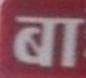

In [16]:
image_sample = read_images(files[0])
image_sample

## Data augumentation
It is the process to augument the data in cases where there are less data or the class is imbalanced.
Here, we have created a function to change the color of an image to augument the data. We change the color of each image until the data points for each label reaches similar quantity.

In [24]:
brightness = T.ColorJitter(brightness=0.2, hue=0.2)
contrast = T.ColorJitter(contrast=10)
rotate = T.RandomRotation(degrees=(15,45))
pers = T.RandomPerspective(distortion_scale=0.2,p=1)
blur = T.GaussianBlur(kernel_size=7, sigma=(0.7, 2.0))
transformation_list=[brightness, contrast, rotate, blur, pers]
# T.Grayscale()(image_path)

In [101]:
# Function to augument the images and store it in new path.
def augument_dataset(orgi_dataset,augument_path, verbose=False):
    if not os.path.exists(augument_path):
        os.makedirs(augument_path)
        
    classes = dict(orgi_dataset.Labels.value_counts())
    final_aug_value = 500
    if verbose:
        count_range = tqdm(classes.items())

    for key, value in count_range:
        
        matched_label = orgi_dataset.loc[orgi_dataset["Labels"] == key]
        matched_images_list = matched_label["Images"].to_list()
        count_diff = final_aug_value - value
        
        if verbose:    
            count_range.set_description(f"Working on adding {count_diff} for label: {key}")
        else:
            count_range = range(count_diff)

        for i in range(count_diff):
            transformation = random.choice(transformation_list)
            image_path = random.choice(matched_images_list)
            filename = f"{transformation._get_name()}_{image_path.split('/')[-1]}"
            class_name = str(key)
            dst_path = f"{augument_path}/{class_name}/{i}_{filename}"
            
            if verbose:
                count_range.set_postfix_str(f"Transformation: {transformation._get_name()}")
            
            if not os.path.exists(augument_path+ "/" + str(class_name)):
                os.makedirs(augument_path+ "/" + str(class_name))
                
            image = read_images(image_path)
            transformed_image = transformation(image)
            transformed_image.save(dst_path)

In [102]:
path = "/home/ml-shailesh/Desktop/PProject/nepali-text-classification/Transformed"
augument_dataset(orgi_dataset = dataset_df, augument_path=path, verbose=True)

Working on adding 404 for label: 0: 100%|██████████| 12/12 [01:41<00:00,  8.49s/it, Transformation: RandomRotation]   


In [103]:
augumented_path = "/home/ml-shailesh/Desktop/PProject/nepali-text-classification/Transformed"
augumented_files = read_data_path(path=augumented_path)
aug_dataset_df = make_data_csv(image_path_list=augumented_files, transform_data=True)

In [104]:
frames = [dataset_df,aug_dataset_df[['Images','Labels']]]
new_df = pd.concat(frames)
new_df.Labels.value_counts()

ba    500
pa    500
0     500
6     500
4     500
7     500
1     500
8     500
9     500
2     500
3     500
5     500
Name: Labels, dtype: int64

## Data Pre-processing

In [10]:
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [11]:
unique_labels = new_df["Labels"].unique().tolist()
def find_boolean_labels(data, unique_labels, label_name):
        labels = []
        for items in data[label_name]:
            map_array = np.zeros(len(unique_labels), dtype=int)
            for idx, label in enumerate(unique_labels):
                for item in items.split(","):
                    if label == item:
                        map_array[idx] = 1
            labels.append(list(map_array))
        data["one_hot_encoded_labels"] = labels

        return data


In [12]:
new_data = find_boolean_labels(new_df, unique_labels, "Labels")

In [89]:
class HandWrittenImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, num_images=None):
        self.dataset = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_path = self.dataset.iloc[idx]["Images"]
#         one_hot_label = self.dataset.iloc[idx]["one_hot_encoded_labels"]
        one_hot_label = torch.tensor(self.dataset.iloc[idx]["one_hot_encoded_labels"])
        label = self.dataset.iloc[idx]["Labels"]
        img = Image.open(img_path)

        if self.transform:
            img = self.transform(img)

        return img, one_hot_label, label


In [90]:
transform = T.Compose([
    T.Resize((64,64)),  # Resize image to 28x28
    T.Grayscale(),  # Convert image to grayscale
    T.ToTensor(),  # Convert image to tensor
    T.Normalize((0.5,), (0.5,))  # Normalize image
])

In [91]:
train_dataset = new_data.sample(n=8)

In [92]:
dataset = HandWrittenImageDataset(train_dataset, transform=transform)

In [93]:
train_dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


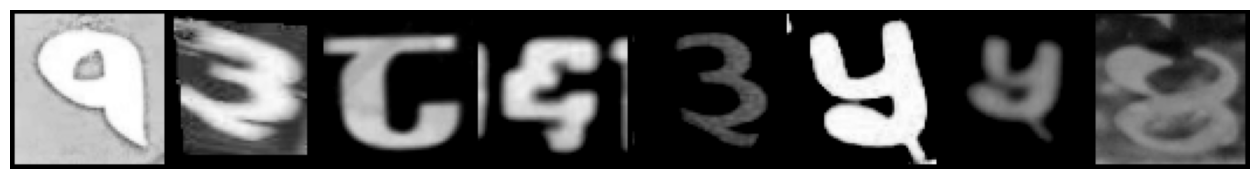

In [94]:
# Iterate over the DataLoader and display a grid of images
for i, (images, labels, _) in enumerate(train_dataloader):
    # Create a grid of images from the batch tensor
    grid = vutils.make_grid(images, nrow=8, padding=2)
    
    # Display the grid of images using matplotlib or any other plotting library
    import matplotlib.pyplot as plt
    plt.figure(figsize=(16, 16))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

In [82]:
images, labels, _ = next(iter(train_dataloader))
#  = dataiter.next()

print(images.shape)
print(_.shape)

torch.Size([8, 1, 64, 64])


AttributeError: 'tuple' object has no attribute 'shape'

## Model Training